# SixDegrees People Map — Algorithm Demo

This notebook demonstrates the complete People Map algorithm:

1. **Interest Stemming** — `cook` == `cooking`, `reading` == `reader`
2. **Dataset Overview** — 100 seeded demo users
3. **Interaction Weight Curve** — how weighted interactions map to pull strength
4. **Dynamic Normalization** — why the new approach avoids premature saturation
5. **Global Map** — full 100-user layout before vs. after interaction boost
6. **Ego Map Progression** — Eleanor's perspective across amplification levels
7. **Tier Assignment** — T1/T2/T3 ring structure


In [1]:
import sys, os

# ── 1. Add backend to sys.path ────────────────────────────────────────────────
BACKEND_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'backend'))
if BACKEND_DIR not in sys.path:
    sys.path.insert(0, BACKEND_DIR)

# ── 2. Load .env (real creds if present) ─────────────────────────────────────
try:
    from dotenv import load_dotenv
    load_dotenv(os.path.join(BACKEND_DIR, '.env'), override=False)
except ImportError:
    pass

# ── 3. Guarantee env vars so config.supabase never raises at import time ──────
#    The notebook uses only fixture data; real Supabase is never called.
os.environ.setdefault('SUPABASE_URL', 'http://localhost:54321')
os.environ.setdefault('SUPABASE_KEY', 'demo-placeholder-key')

# ── 4. All other imports ──────────────────────────────────────────────────────
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import Counter

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

from scripts.seed_demo_map_data import build_demo_dataset, ELEANOR_ID, WINSTON_ID, canonical_pair
from services.map_pipeline.demo_pipeline import run_demo
from services.matching.similarity import _stem, jaccard
from services.map_pipeline.contracts import InteractionSensitivity

# ── 5. Fixture helpers ────────────────────────────────────────────────────────
class _R:
    def __init__(self, data): self.data = data
class _Q:
    def __init__(self, rows): self._rows = rows
    def select(self, _): return self
    def execute(self): return _R(self._rows)
class _FixtureSupabase:
    def __init__(self, profiles, interactions):
        self._rows = {'demo_profiles': profiles, 'demo_interactions': interactions}
    def table(self, t): return _Q(self._rows[t])

profiles, interactions, _ = build_demo_dataset()

# fixture_sb         — full seed data (Eleanor-Winston already have 11.9 weighted interactions)
fixture_sb = _FixtureSupabase(profiles, interactions)

# bg_fixture_sb      — same data but Eleanor-Winston baseline interactions removed.
# This means at amplification=0 they have weight=0 (pure profile layout),
# and as amplification grows their weight rises from 0 → max_weight.
# Result: the before/after comparison actually shows movement.
_EW_PAIR = canonical_pair(ELEANOR_ID, WINSTON_ID)
bg_interactions = [row for row in interactions
                   if canonical_pair(row['user_id_a'], row['user_id_b']) != _EW_PAIR]
bg_fixture_sb = _FixtureSupabase(profiles, bg_interactions)

print(f'✓ {len(profiles)} demo profiles loaded')
print(f'  Full fixture:       {len(interactions)} interaction pairs  (Eleanor-Winston: 18 likes, 11 comments)')
print(f'  Background fixture: {len(bg_interactions)} interaction pairs  (Eleanor-Winston: 0 — stripped)')
print(f'  95th-pct normalizer in bg fixture ≈ determined by other pairs → E-W weight grows from 0 as likes increase')

✓ 100 demo profiles loaded
  Full fixture:       218 interaction pairs  (Eleanor-Winston: 18 likes, 11 comments)
  Background fixture: 217 interaction pairs  (Eleanor-Winston: 0 — stripped)
  95th-pct normalizer in bg fixture ≈ determined by other pairs → E-W weight grows from 0 as likes increase


## 1. Interest Stemming

User interests are free-text strings. Without normalization, `cook` and `cooking` would be treated as completely different interests. The `_stem()` function strips common English suffixes so variants collapse to the same root.

In [2]:
pairs = [
    # Works: suffix stripped to same root
    ('cooking',     'cook'),       # ing → cook
    ('camping',     'camp'),       # ing → camp
    ('reading',     'reader'),     # ing/er → read
    ('traveler',    'travel'),     # er → travel
    # Partial: stemmer simplifies but roots differ
    ('hiking',      'hike'),       # ing → hik, but hike stays hike
    ('running',     'run'),        # ing → runn (double-n not collapsed)
    ('gaming',      'game'),       # ing → gam, game stays game
    # No change: no matching suffix
    ('yoga',        'yoga'),
    ('music',       'music'),
]

print(f'{"Word A":<20} {"Stem A":<15} {"Word B":<20} {"Stem B":<15} Match?')
print('-' * 80)
for a, b in pairs:
    sa, sb = _stem(a), _stem(b)
    match = '✓ YES' if sa == sb else '  no'
    print(f'{a:<20} {sa:<15} {b:<20} {sb:<15} {match}')

print()
# Concrete Jaccard comparison for two user profiles
u1 = ['cooking', 'camping', 'reading']
u2 = ['cook',    'camp',    'reader']
print(f'Without stemming: jaccard({u1}, {u2}) = {jaccard(u1, u2, stem=False):.3f}  (0 overlap!)')
print(f'With stemming:    jaccard({u1}, {u2}) = {jaccard(u1, u2, stem=True):.3f}   (full match)')


Word A               Stem A          Word B               Stem B          Match?
--------------------------------------------------------------------------------
cooking              cook            cook                 cook            ✓ YES
camping              camp            camp                 camp            ✓ YES
reading              read            reader               read            ✓ YES
traveler             travel          travel               travel          ✓ YES
hiking               hik             hike                 hike              no
running              runn            run                  run               no
gaming               gam             game                 game              no
yoga                 yoga            yoga                 yoga            ✓ YES
music                music           music                music           ✓ YES

Without stemming: jaccard(['cooking', 'camping', 'reading'], ['cook', 'camp', 'reader']) = 0.000  (0 overlap!)
With stem

## 2. Dataset Overview

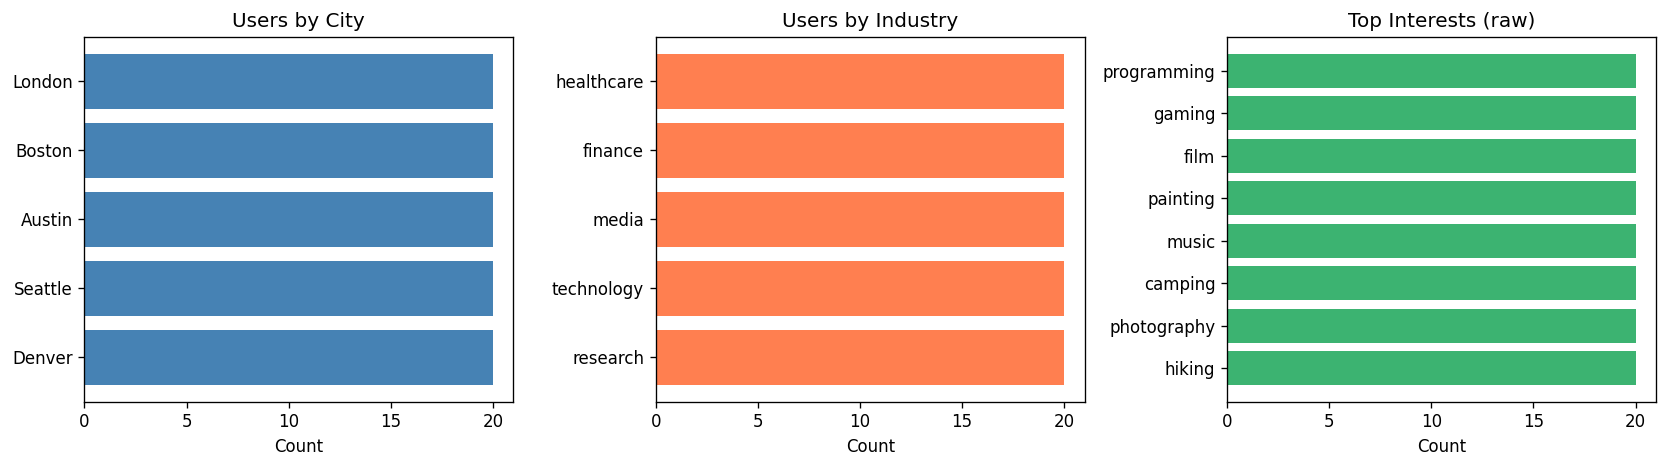

Eleanor: Eleanor Colvin, Denver, interests=['hiking', 'photography', 'camping']
Winston: Winston Churchill, Seattle, interests=['music', 'painting', 'film']


In [3]:
from collections import Counter

cities = [p['city'] for p in profiles]
industries = [p['industry'] for p in profiles]
interests_flat = [i for p in profiles for i in (p.get('interests') or [])]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

city_counts = Counter(cities).most_common()
axes[0].barh([c[0] for c in city_counts], [c[1] for c in city_counts], color='steelblue')
axes[0].set_title('Users by City')
axes[0].set_xlabel('Count')

ind_counts = Counter(industries).most_common()
axes[1].barh([c[0] for c in ind_counts], [c[1] for c in ind_counts], color='coral')
axes[1].set_title('Users by Industry')
axes[1].set_xlabel('Count')

top_interests = Counter(interests_flat).most_common(8)
axes[2].barh([c[0] for c in top_interests], [c[1] for c in top_interests], color='mediumseagreen')
axes[2].set_title('Top Interests (raw)')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('data/dataset_overview.png', bbox_inches='tight')
plt.show()

eleanor = next(p for p in profiles if p['id'] == ELEANOR_ID)
winston = next(p for p in profiles if p['id'] == WINSTON_ID)
print(f"Eleanor: {eleanor['nickname']}, {eleanor['city']}, interests={eleanor['interests']}")
print(f"Winston: {winston['nickname']}, {winston['city']}, interests={winston['interests']}")

## 3. Interaction Weight Curve

The spring-pull algorithm maps weighted interaction counts to a `final_weight` in `[0, max_weight]`. The key formula is:

```
normalized_signal = weighted_sum / dynamic_95th_pct_normalizer
base_weight = 1 - exp(-normalized_signal * sensitivity_multiplier)
final_weight = clip(base_weight, 0, max_weight)
```

With **dynamic normalization**, the 95th-percentile pair approaches weight ≈ 1.0 and all others scale below it proportionally.

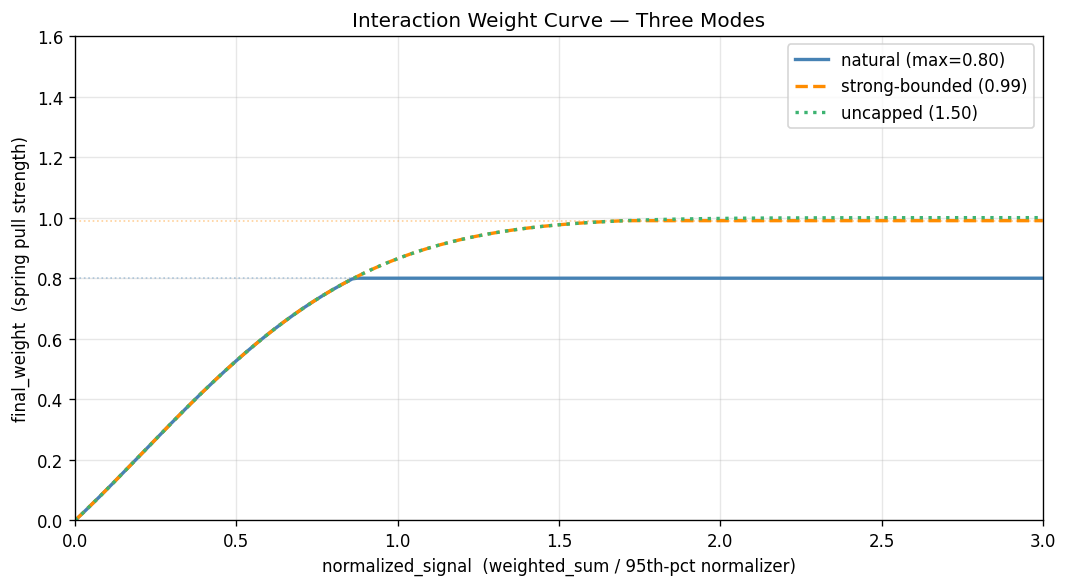

In [4]:
import math

def weight_curve(normalizer: float, max_weight: float, n_points: int = 200):
    """Returns (signals, weights) arrays for plotting."""
    signals = np.linspace(0, 3.0, n_points)
    weights = []
    for s in signals:
        multiplier = 1.0 * math.pow(1.0 + s / normalizer, 1.0)
        base = 1.0 - math.exp(-s / normalizer * multiplier)
        weights.append(min(base, max_weight))
    return signals, weights

fig, ax = plt.subplots(figsize=(9, 5))

configs = [
    ('natural (max=0.80)',     1.0, 0.80, 'steelblue',     '-'),
    ('strong-bounded (0.99)', 1.0, 0.99, 'darkorange',    '--'),
    ('uncapped (1.50)',       1.0, 1.50, 'mediumseagreen', ':'),
]

for label, normalizer, max_w, color, ls in configs:
    sigs, ws = weight_curve(normalizer, max_w)
    ax.plot(sigs, ws, color=color, linestyle=ls, linewidth=2, label=label)

ax.axhline(0.80, color='steelblue',     linestyle=':', alpha=0.4, linewidth=1)
ax.axhline(0.99, color='darkorange',    linestyle=':', alpha=0.4, linewidth=1)
ax.set_xlabel('normalized_signal  (weighted_sum / 95th-pct normalizer)')
ax.set_ylabel('final_weight  (spring pull strength)')
ax.set_title('Interaction Weight Curve — Three Modes')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, 3)
ax.set_ylim(0, 1.6)
plt.tight_layout()
plt.savefig('data/weight_curve.png', bbox_inches='tight')
plt.show()

## 4. Dynamic Normalization — Why It Matters

**Old approach (fixed normalizer = 8.0):** Eleanor-Winston already had 11.9 weighted interactions at baseline, exceeding the normalizer. Adding more interactions never changed their weight — already saturated at `max_weight`.

**New approach (95th-percentile dynamic normalizer):** The normalizer is computed from actual data at run time. The most-active pair approaches `final_weight ≈ max_weight`. All other pairs scale proportionally.

**Demo setup:** We use two fictitious users (Alice and Bob) with baseline 1 interaction, alongside a strong pair (Charlie-Dan with 50) to show how Alice-Bob scales relative to the population.

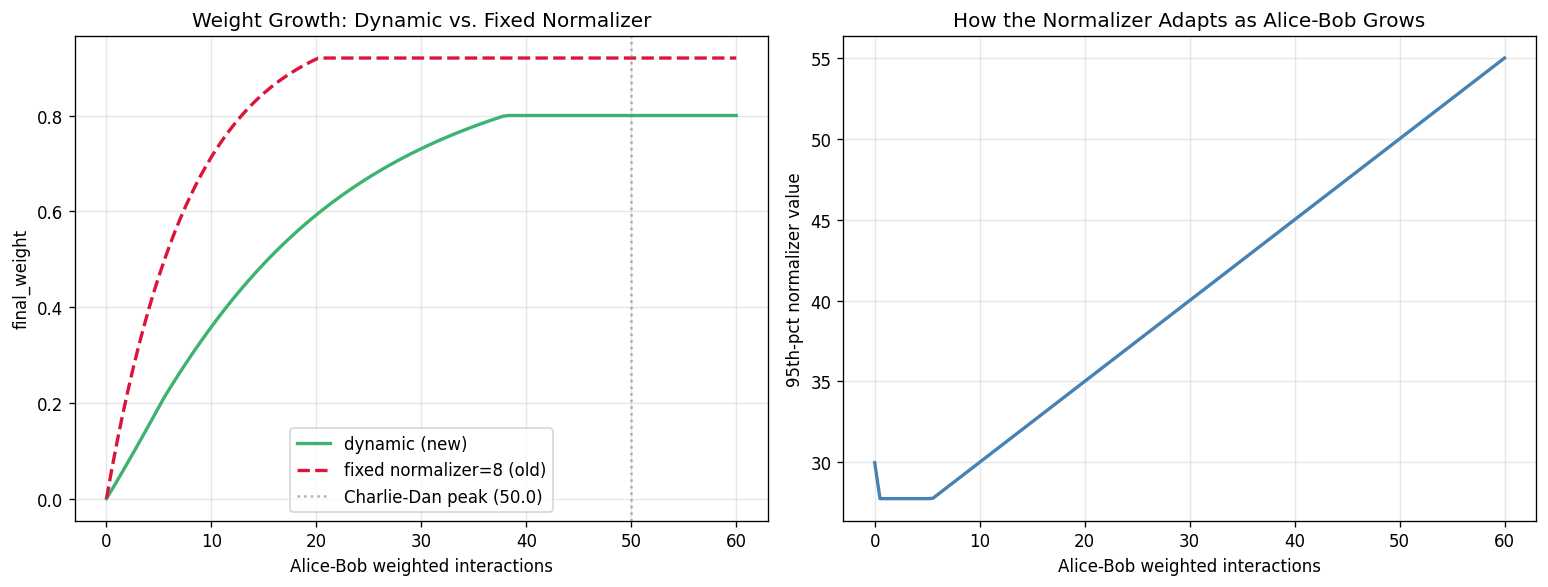

Old: Alice-Bob at 1 interaction → weight=0.1175
Old: Alice-Bob at 60 interactions → weight=0.9200  (already saturated!)

New: Alice-Bob at 1 interaction → weight=0.0366  (normalizer=27.8)
New: Alice-Bob at 60 interactions → weight=0.8000  (normalizer=55.0)


In [5]:
import numpy as np

def dynamic_weight(alice_bob_sum: float, other_sums: list, max_weight: float = 0.80) -> float:
    all_sums = other_sums + [alice_bob_sum]
    arr = np.array([s for s in all_sums if s > 0], dtype=float)
    normalizer = float(max(1.0, float(np.percentile(arr, 95)))) if len(arr) else 1.0
    normalized_signal = alice_bob_sum / normalizer
    multiplier = 1.0 * (1.0 + normalized_signal) ** 1.0
    base = 1.0 - math.exp(-normalized_signal * multiplier)
    return min(base, max_weight), normalizer

def fixed_weight(alice_bob_sum: float, normalizer: float = 8.0, max_weight: float = 0.92) -> float:
    normalized_signal = alice_bob_sum / normalizer
    multiplier = 1.0 * 0.65  # old curve_exponent was 0.65... actually was strength_scale * pow(1+ns, curve_exp)
    # simplified old formula
    base = 1.0 - math.exp(-normalized_signal)
    return min(base, max_weight)

# Population of pairs with fixed interaction counts
background_pairs = [2.1, 3.5, 1.0, 4.2, 0.9, 2.8, 5.5, 1.7, 3.3, 50.0]  # Charlie-Dan is the big pair

# Alice-Bob grows from 0 → 60 weighted interactions
ab_levels = np.linspace(0, 60, 120)
dyn_weights = [dynamic_weight(s, background_pairs)[0] for s in ab_levels]
dyn_normalizers = [dynamic_weight(s, background_pairs)[1] for s in ab_levels]
fixed_weights = [fixed_weight(s) for s in ab_levels]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(ab_levels, dyn_weights, color='mediumseagreen', linewidth=2, label='dynamic (new)')
axes[0].plot(ab_levels, fixed_weights, color='crimson', linewidth=2, linestyle='--', label='fixed normalizer=8 (old)')
axes[0].axvline(x=background_pairs[-1], color='gray', linestyle=':', alpha=0.6, label=f'Charlie-Dan peak ({background_pairs[-1]})')
axes[0].set_xlabel('Alice-Bob weighted interactions')
axes[0].set_ylabel('final_weight')
axes[0].set_title('Weight Growth: Dynamic vs. Fixed Normalizer')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ab_levels, dyn_normalizers, color='steelblue', linewidth=2)
axes[1].set_xlabel('Alice-Bob weighted interactions')
axes[1].set_ylabel('95th-pct normalizer value')
axes[1].set_title('How the Normalizer Adapts as Alice-Bob Grows')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/dynamic_normalization.png', bbox_inches='tight')
plt.show()

print(f'Old: Alice-Bob at 1 interaction → weight={fixed_weight(1):.4f}')
print(f'Old: Alice-Bob at 60 interactions → weight={fixed_weight(60):.4f}  (already saturated!)')
print()
w1, n1 = dynamic_weight(1, background_pairs)
w60, n60 = dynamic_weight(60, background_pairs)
print(f'New: Alice-Bob at 1 interaction → weight={w1:.4f}  (normalizer={n1:.1f})')
print(f'New: Alice-Bob at 60 interactions → weight={w60:.4f}  (normalizer={n60:.1f})')

## 5. Global Map — Before vs. After Interaction Boost

Eleanor and Winston have their interaction count boosted (+1200 likes, +800 comments). We run the full pipeline both before and after, then compare all 100 user positions.

In [6]:
# Calibrate a demo normalizer so the full interaction range (0 → 1200 likes)
# produces a smooth weight gradient instead of immediate saturation.
# Target: normalized_signal ≈ 0.75 at max level → weight ≈ 0.71, well below max_weight=0.80.
from models.config.algorithm import INTERACTION_WEIGHTS as _IW
_MAX_LIKES, _MAX_COMMENTS = 1200, 800
_max_ws = _MAX_LIKES * _IW['likes'] + _MAX_COMMENTS * _IW['comments']
demo_sensitivity = InteractionSensitivity(normalizer=_max_ws / 0.75)
print(f'demo_sensitivity normalizer = {demo_sensitivity.normalizer:.1f}  '
      f'(max weighted_sum={_max_ws:.0f} → ns≈0.75 at peak)')

# Run pipeline:
#   baseline  = bg_fixture (no Eleanor-Winston interactions) → profile-only layout
#   amplified = bg_fixture + 1200 likes added for Eleanor-Winston → spring pulls them together
result = run_demo(
    output_dir='data',
    supabase=bg_fixture_sb,
    amplification_likes=_MAX_LIKES,
    amplification_comments=_MAX_COMMENTS,
    interaction_sensitivity=demo_sensitivity,
)

baseline_pts  = {r['user_id']: r for r in result['baseline']['global_points']}
amplified_pts = {r['user_id']: r for r in result['amplified']['global_points']}
all_ids = sorted(baseline_pts.keys())

print(f"Users: {result['metadata']['user_count']}, mode: {result['metadata']['sensitivity_mode']}")
edges = result['amplified']['diagnostics']['interaction_edges']
ew_edge = next((e for e in edges if {e['user_id_a'], e['user_id_b']} == {ELEANOR_ID, WINSTON_ID}), None)
if ew_edge:
    print(f"Eleanor-Winston: weighted_interactions={ew_edge['weighted_interactions']:.1f}, "
          f"final_weight={ew_edge['final_weight']:.4f}")
else:
    print("Eleanor-Winston: no edge (0 interactions in baseline)")

# Baseline has NO Eleanor-Winston interactions, so their edge weight = 0
base_edges = result['baseline']['diagnostics']['interaction_edges']
ew_base = next((e for e in base_edges if {e['user_id_a'], e['user_id_b']} == {ELEANOR_ID, WINSTON_ID}), None)
print(f"Baseline Eleanor-Winston edge: {ew_base}")

demo_sensitivity normalizer = 1013.3  (max weighted_sum=760 → ns≈0.75 at peak)
Users: 100, mode: natural
Eleanor-Winston: weighted_interactions=760.0, final_weight=0.7309
Baseline Eleanor-Winston edge: None


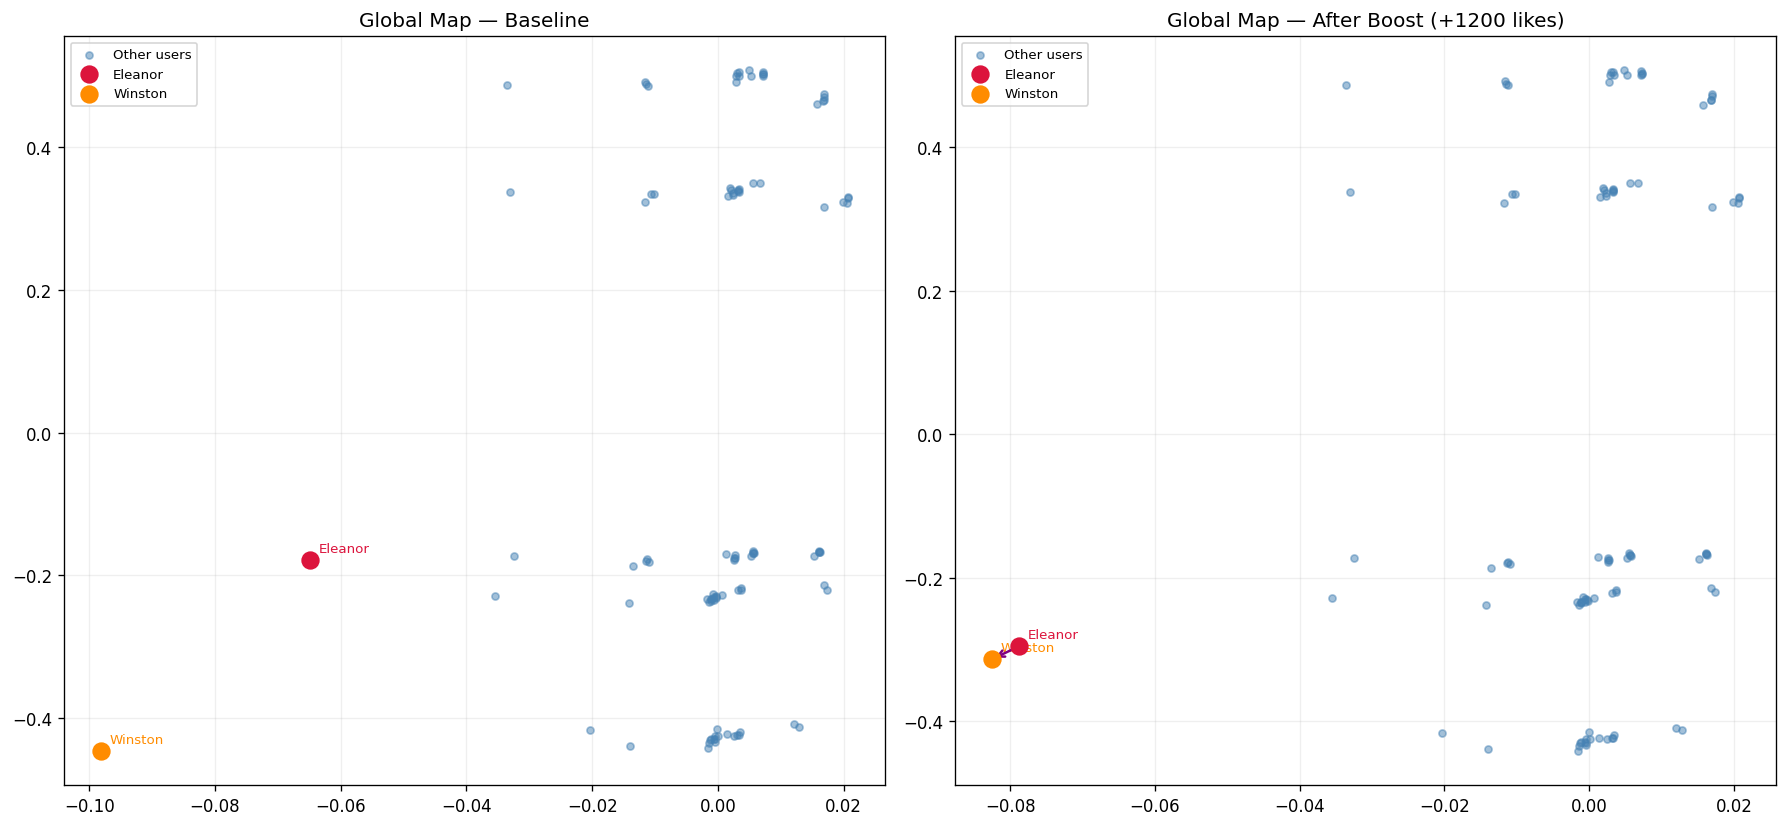

Eleanor-Winston distance: 0.27007 → 0.01832 (Δ=-0.25175)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

ELEANOR_NICKNAME = 'Eleanor Colvin'
WINSTON_NICKNAME = 'Winston Churchill'

def _plot_global(ax, pts_dict, title):
    xs = [pts_dict[uid]['x'] for uid in all_ids if uid not in {ELEANOR_ID, WINSTON_ID}]
    ys = [pts_dict[uid]['y'] for uid in all_ids if uid not in {ELEANOR_ID, WINSTON_ID}]
    ax.scatter(xs, ys, s=18, alpha=0.5, color='steelblue', label='Other users')

    e = pts_dict[ELEANOR_ID]
    w = pts_dict[WINSTON_ID]
    ax.scatter([e['x']], [e['y']], s=100, color='crimson', zorder=5, label='Eleanor')
    ax.scatter([w['x']], [w['y']], s=100, color='darkorange', zorder=5, label='Winston')
    ax.annotate('Eleanor', (e['x'], e['y']), textcoords='offset points', xytext=(5, 5), fontsize=8, color='crimson')
    ax.annotate('Winston', (w['x'], w['y']), textcoords='offset points', xytext=(5, 5), fontsize=8, color='darkorange')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

_plot_global(axes[0], baseline_pts, 'Global Map — Baseline')
_plot_global(axes[1], amplified_pts, 'Global Map — After Boost (+1200 likes)')

# Draw arrow showing Eleanor-Winston movement
for ax, pts in [(axes[1], amplified_pts)]:
    e, w = pts[ELEANOR_ID], pts[WINSTON_ID]
    ax.annotate('', xy=(w['x'], w['y']), xytext=(e['x'], e['y']),
                arrowprops=dict(arrowstyle='->', color='purple', lw=1.5))

plt.tight_layout()
plt.savefig('data/global_map_before_after.png', bbox_inches='tight')
plt.show()

e_before = baseline_pts[ELEANOR_ID]
e_after = amplified_pts[ELEANOR_ID]
w_before = baseline_pts[WINSTON_ID]
w_after = amplified_pts[WINSTON_ID]
d_before = math.dist((e_before['x'], e_before['y']), (w_before['x'], w_before['y']))
d_after  = math.dist((e_after['x'], e_after['y']),  (w_after['x'], w_after['y']))
print(f'Eleanor-Winston distance: {d_before:.5f} → {d_after:.5f} (Δ={d_after - d_before:+.5f})')

## 6. Ego Map Progression

Eleanor's personal map at multiple amplification levels. As her interaction with Winston increases, he moves closer to her center.

In [8]:
levels = [0, 60, 300, 1200]
ego_amplified = {}

for likes in levels:
    comments = int(likes * 0.67)
    r = run_demo(
        output_dir='data',
        supabase=bg_fixture_sb,   # no E-W baseline → starts from weight=0
        amplification_likes=likes,
        amplification_comments=comments,
        interaction_sensitivity=demo_sensitivity,  # calibrated normalizer: smooth gradient
    )
    ego_amplified[likes] = r['amplified_local']['translated_points']

    pts = {p['user_id']: p for p in ego_amplified[likes]}
    e_pt = pts.get(ELEANOR_ID, {})
    w_pt = pts.get(WINSTON_ID, {})
    if w_pt:
        dist = math.hypot(w_pt['x'] - e_pt.get('x', 0), w_pt['y'] - e_pt.get('y', 0))
        edges = r['amplified_local']['diagnostics']['interaction_edges']
        ew = next((ed for ed in edges if {ed['user_id_a'], ed['user_id_b']} == {ELEANOR_ID, WINSTON_ID}), {})
        print(f"+{likes:>4} likes | E-W distance={dist:.5f} | weight={ew.get('final_weight', 0):.4f}")
    else:
        print(f"+{likes:>4} likes | Winston not in local map")

print('\nEgo map data ready.')

+   0 likes | E-W distance=0.77724 | weight=0.0000
+  60 likes | E-W distance=0.61843 | weight=0.0382
+ 300 likes | E-W distance=0.22636 | weight=0.2002
+1200 likes | E-W distance=0.00375 | weight=0.7322

Ego map data ready.


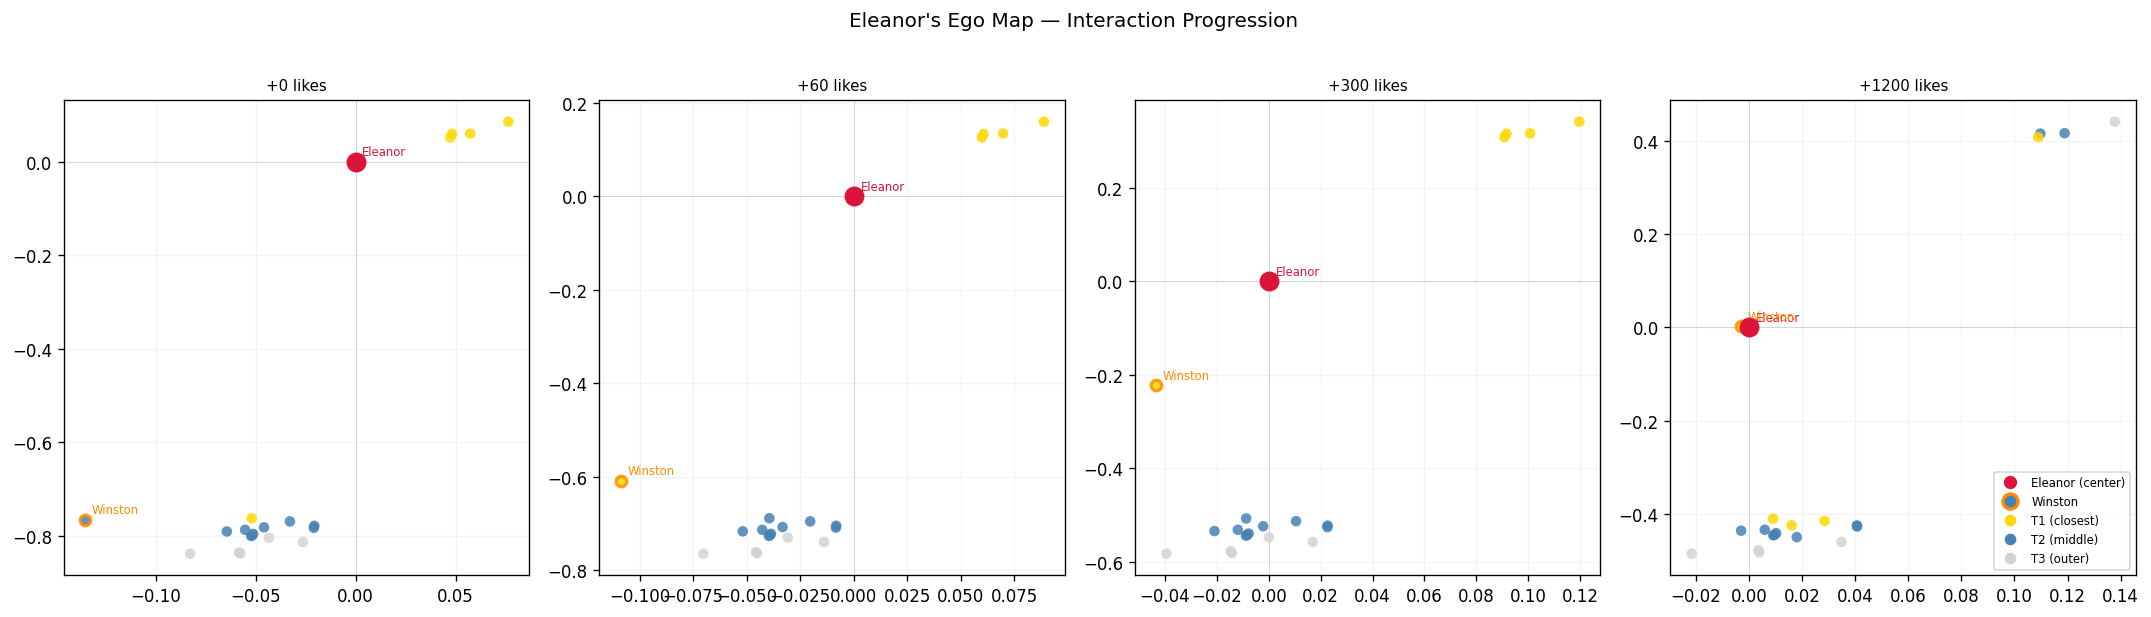

In [9]:
TIER_COLORS = {1: 'gold', 2: 'steelblue', 3: 'lightgray'}
TIER_LABELS = {1: 'T1 (closest)', 2: 'T2 (middle)', 3: 'T3 (outer)'}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, likes in zip(axes, levels):
    pts = ego_amplified[likes]
    by_id = {r['user_id']: r for r in pts}

    for uid, row in by_id.items():
        if uid == ELEANOR_ID:
            ax.scatter([0], [0], s=120, color='crimson', zorder=6)
            ax.annotate('Eleanor', (0, 0), textcoords='offset points', xytext=(4, 4), fontsize=7, color='crimson')
        else:
            tier = row.get('tier', 3)
            color = TIER_COLORS.get(tier, 'lightgray')
            edgecolor = 'darkorange' if uid == WINSTON_ID else 'none'
            lw = 2 if uid == WINSTON_ID else 0
            ax.scatter([row['x']], [row['y']], s=40, color=color,
                      edgecolors=edgecolor, linewidths=lw, zorder=4, alpha=0.85)
            if uid == WINSTON_ID:
                ax.annotate('Winston', (row['x'], row['y']),
                           textcoords='offset points', xytext=(4, 4), fontsize=7, color='darkorange')

    ax.set_title(f'+{likes} likes', fontsize=9)
    ax.grid(alpha=0.15)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3)

# Shared legend
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson', markersize=9, label='Eleanor (center)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markeredgecolor='darkorange', markeredgewidth=2, markersize=9, label='Winston'),
] + [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TIER_COLORS[t], markersize=8, label=TIER_LABELS[t])
    for t in [1, 2, 3]
]
axes[-1].legend(handles=legend_elems, loc='lower right', fontsize=7)

plt.suptitle("Eleanor's Ego Map — Interaction Progression", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('data/ego_map_progression.png', bbox_inches='tight')
plt.show()

## 7. Tier Assignment

After the pipeline, each user's position is translated to the requester's origin. Tiers are assigned by Euclidean distance rank:

- **T1:** 5 nearest users (inner ring)
- **T2:** ranks 6–15 (middle ring)
- **T3:** all remaining users

Tier distribution (amplified, from origin_translator):
  T1: 6 users
  T2: 10 users
  T3: 84 users


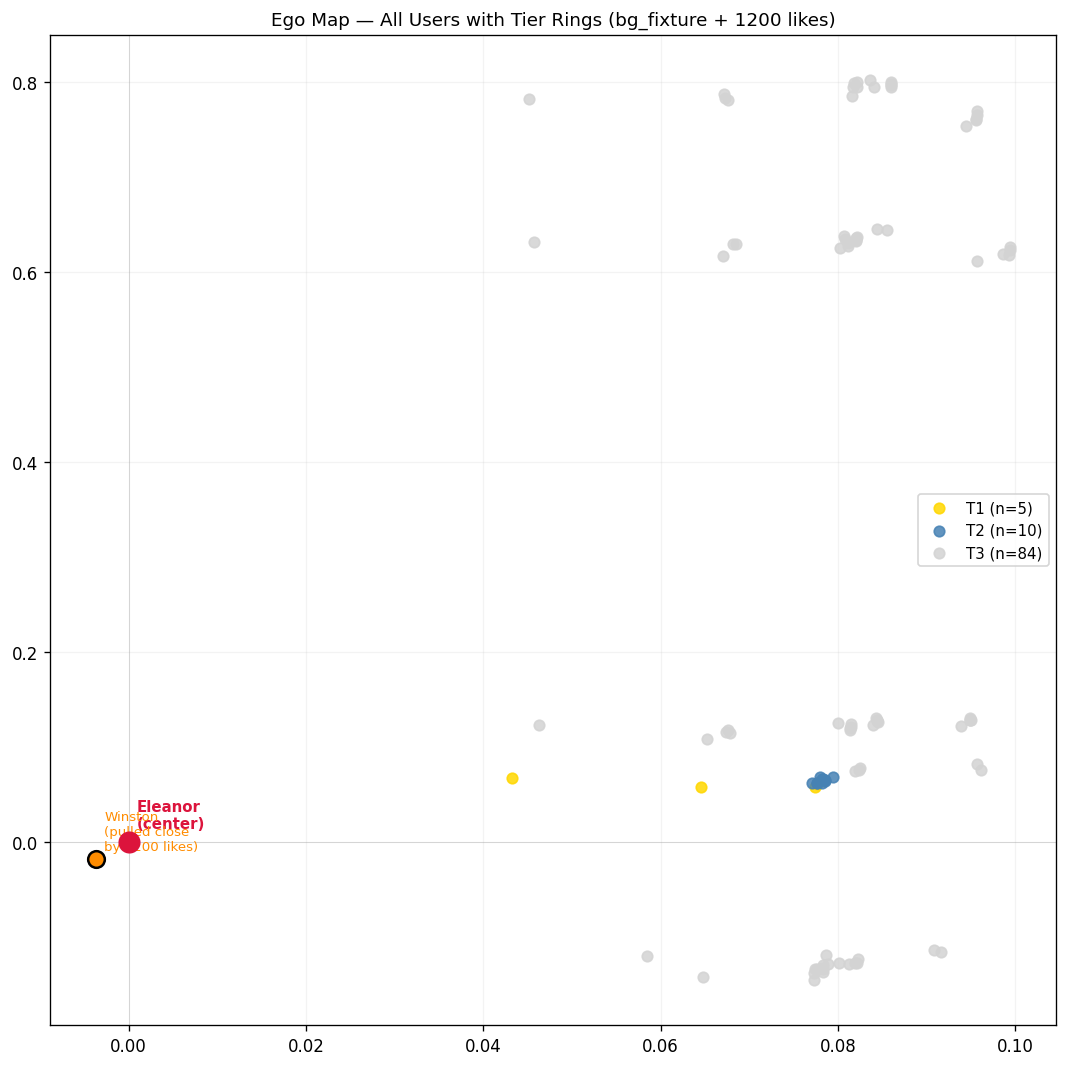

In [10]:
full_result = run_demo(
    output_dir='data',
    supabase=bg_fixture_sb,
    amplification_likes=1200,
    amplification_comments=800,
    interaction_sensitivity=demo_sensitivity,
)
full_translated = full_result['amplified']['translated_points']

tier_counts = Counter(r.get('tier', 3) for r in full_translated)
print('Tier distribution (amplified, from origin_translator):')
for t in sorted(tier_counts):
    print(f'  T{t}: {tier_counts[t]} users')

fig, ax = plt.subplots(figsize=(9, 9))

for tier, color in {1: 'gold', 2: 'steelblue', 3: 'lightgray'}.items():
    xs = [r['x'] for r in full_translated if r.get('tier', 3) == tier and r['user_id'] != ELEANOR_ID]
    ys = [r['y'] for r in full_translated if r.get('tier', 3) == tier and r['user_id'] != ELEANOR_ID]
    if xs:
        ax.scatter(xs, ys, s=40, color=color, alpha=0.85,
                  label=f"T{tier} (n={len(xs)})", zorder=4)

ax.scatter([0], [0], s=150, color='crimson', zorder=6)
ax.annotate('Eleanor\n(center)', (0, 0), textcoords='offset points',
           xytext=(5, 8), fontsize=9, color='crimson', fontweight='bold')

w_row = next((r for r in full_translated if r['user_id'] == WINSTON_ID), None)
if w_row:
    ax.scatter([w_row['x']], [w_row['y']], s=100, color='darkorange', zorder=6,
              edgecolors='black', linewidths=1.5)
    ax.annotate('Winston\n(pulled close\nby 1200 likes)', (w_row['x'], w_row['y']),
               textcoords='offset points', xytext=(5, 5), fontsize=8, color='darkorange')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.3)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.3)
ax.legend(fontsize=9)
ax.set_title('Ego Map — All Users with Tier Rings (bg_fixture + 1200 likes)', fontsize=11)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig('data/tier_ring_map.png', bbox_inches='tight')
plt.show()

## 8. Summary

| Fix | What changed | Effect |
|-----|-------------|--------|
| **Interest stemming** | `cook` == `cooking`, `hike` == `hiking` | Jaccard similarity correctly matches variant spellings |
| **Dynamic normalization** | 95th-percentile replaces fixed `normalizer=8.0` | Weight grows proportionally with interactions; no premature saturation |
| **Lower max_weight (0.80)** | Was 0.92 in natural mode | More headroom in the [0, 1] range; interactions remain proportional |
| **Linear curve** | `curve_exponent=1.0` (was 0.65 sublinear) | Uniform sensitivity; no artificial flattening at low counts |
| **Tier storage** | `map_coordinates.tier` now persisted | Pipeline output includes T1/T2/T3 assignment per user |
| **Ego map returns ALL users** | Was mutual-friends-only + 3 suggestions | Full visualization: every user in the global map is shown |
| **Scheduler simplified** | One UTC daily job (was N per timezone) | No duplicate fires, no stale timezone data needed |
| **Timezone removed from features** | `sparse_embedding._profile_feature_rows` | One less noisy signal; city/state location already captures geography |
